In [1]:
!git clone https://github.com/SIAM0808/Artificial_Intelligence_and_Machine_Learning_Lab.git
%cd Artificial_Intelligence_and_Machine_Learning_Lab

import os

print(os.listdir())
print(os.listdir("K_MeansClustering"))
print(os.listdir("K_MeansClustering/dataset"))

fatal: destination path 'Artificial_Intelligence_and_Machine_Learning_Lab' already exists and is not an empty directory.
/content/Artificial_Intelligence_and_Machine_Learning_Lab
['LinearRegression', '220124_links.pdf', 'cluster_scatter.png', 'LogisticRegression', 'SVM & KNN', 'elbow_curve.png', 'custom_data_clusters.png', 'K_MeansClustering', '.git', 'scaler.pkl', 'kmeans_model.pkl']
['dataset']
['Mall_Customers.csv', 'custom_data.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

In [3]:
df = pd.read_csv("K_MeansClustering/dataset/Mall_Customers.csv")

print(" Shape:", df.shape)
print("\n First 5 rows:")
print(df.head())
print("\n Columns:", df.columns.tolist())

 Shape: (200, 5)

 First 5 rows:
   CustomerID  Gender  Age  AnnualIncome  SpendingScore
0           1    Male   19         15000             39
1           2    Male   21         15000             81
2           3  Female   20         16000              6
3           4  Female   23         16000             77
4           5  Female   31         17000             40

 Columns: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']


# Clean Column

In [4]:

df.columns = df.columns.str.strip()
print("Columns now:", df.columns.tolist())

rename_map = {}
for col in df.columns:
    if "income" in col.lower():
        rename_map[col] = "Annual Income (k$)"
    elif "spending" in col.lower():
        rename_map[col] = "Spending Score (1-100)"
    elif col.lower() == "age":
        rename_map[col] = "Age"

df = df.rename(columns=rename_map)
print("\n Final columns:", df.columns.tolist())
print(df.head())

Columns now: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

 Final columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19               15000                      39
1           2    Male   21               15000                      81
2           3  Female   20               16000                       6
3           4  Female   23               16000                      77
4           5  Female   31               17000                      40


# Select Features and Scale (Preprocessing)

In [5]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = df[features].values

print(" Feature matrix shape:", X.shape)
print("First 5 rows (before scaling):")
print(X[:5])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows (after scaling):")
print(X_scaled[:5])
print("\n Scaling complete!")

 Feature matrix shape: (200, 2)
First 5 rows (before scaling):
[[15000    39]
 [15000    81]
 [16000     6]
 [16000    77]
 [17000    40]]

First 5 rows (after scaling):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]

 Scaling complete!


# Elbow Method (Find Optimal K)

  K= 1 | WCSS = 400.00
  K= 2 | WCSS = 269.69
  K= 3 | WCSS = 157.70
  K= 4 | WCSS = 108.92
  K= 5 | WCSS = 65.57
  K= 6 | WCSS = 55.06
  K= 7 | WCSS = 44.86
  K= 8 | WCSS = 37.23
  K= 9 | WCSS = 32.39
  K=10 | WCSS = 29.98


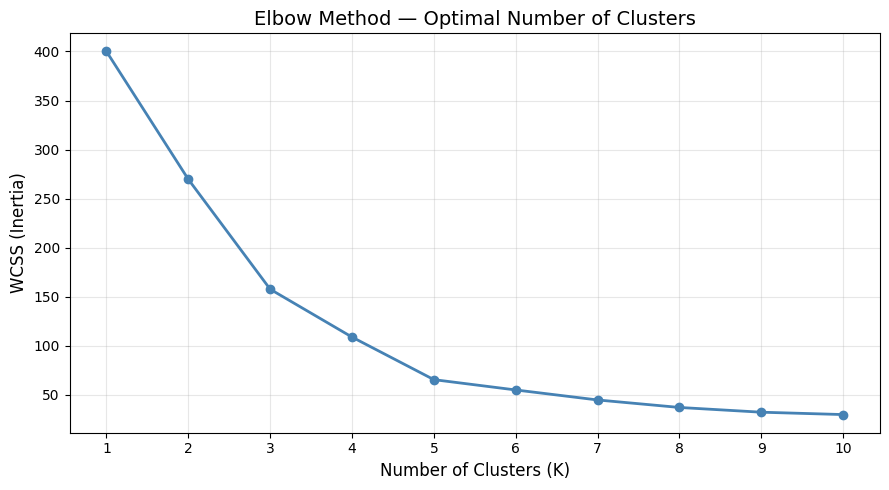


 Elbow curve saved!
💡 Look for the 'bend' (elbow) in the curve — that's your optimal K.
   For Mall Customers data, K=5 is typically the best choice.


In [6]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f"  K={k:2d} | WCSS = {kmeans.inertia_:.2f}")

#elbow curve
plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, marker='o', linewidth=2, color='steelblue')
plt.title("Elbow Method — Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("WCSS (Inertia)", fontsize=12)
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()

print("\n Elbow curve saved!")
print("💡 Look for the 'bend' (elbow) in the curve — that's your optimal K.")
print("   For Mall Customers data, K=5 is typically the best choice.")

# Fit the Final Model with Optimal K

In [7]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
kmeans.fit(X_scaled)

df["Cluster"] = kmeans.labels_

print(f" Model trained with K={optimal_k} clusters!")
print("\nNumber of customers in each cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nCluster centers (in scaled space):")
print(kmeans.cluster_centers_)

 Model trained with K=5 clusters!

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster centers (in scaled space):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


# Cluster Scatter Plot with Centroids

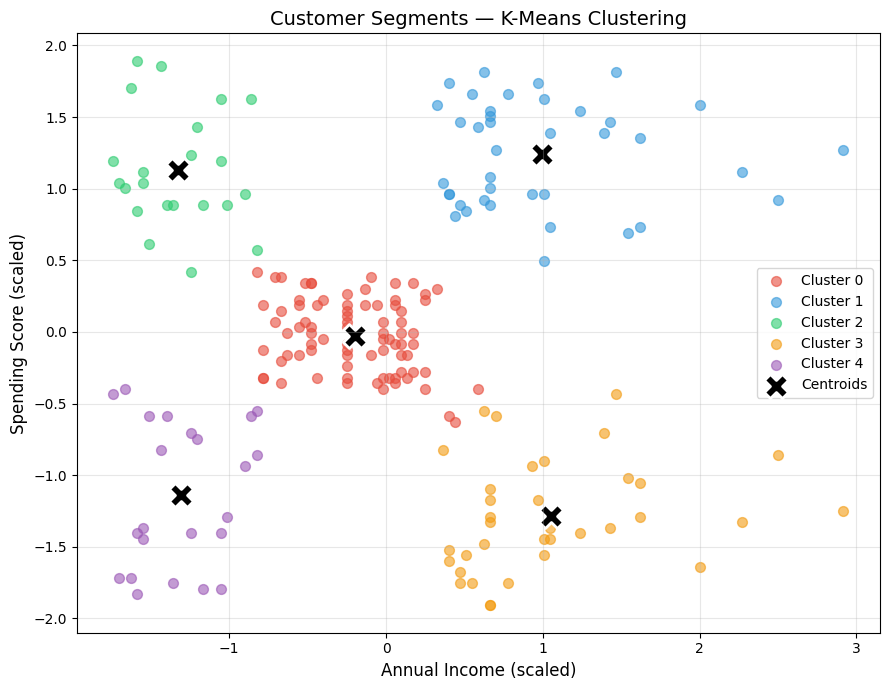

In [8]:
plt.figure(figsize=(9, 7))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for cluster_id in range(optimal_k):
    cluster_points = X_scaled[kmeans.labels_ == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                s=50, c=colors[cluster_id % len(colors)],
                label=f"Cluster {cluster_id}", alpha=0.6)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='black', marker='X', label='Centroids', edgecolors='white', linewidths=2)

plt.title("Customer Segments — K-Means Clustering", fontsize=14)
plt.xlabel("Annual Income (scaled)", fontsize=12)
plt.ylabel("Spending Score (scaled)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150)
plt.show()


# Interpret the Clusters

In [9]:
# Show average values per cluster (in original, unscaled units)
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Count"] = df["Cluster"].value_counts().sort_index()

print("=" * 70)
print("           CLUSTER PROFILES (Average Values)")
print("=" * 70)
print(cluster_summary)
print("=" * 70)

           CLUSTER PROFILES (Average Values)
          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        42.7             55296.3                    49.5     81
1        32.7             86538.5                    82.1     39
2        25.3             25727.3                    79.4     22
3        41.1             88200.0                    17.1     35
4        45.2             26304.3                    20.9     23


# Save the Trained Model and Scaler

In [10]:
# Save BOTH the model AND scaler together in ONE file (named with your Student ID)
import joblib

model_package = {
    "model": kmeans,
    "scaler": scaler,
    "features": features
}

joblib.dump(model_package, "220124.pkl")   # <-- replace 190110 with YOUR actual student ID

print(" Saved 220124.pkl (contains both model and scaler)")

 Saved 220124.pkl (contains both model and scaler)


# Load Custom Data and Predict

In [12]:

# Load the combined model package
model_package = joblib.load("220124.pkl")

kmeans = model_package["model"]
scaler = model_package["scaler"]
features = model_package["features"]

custom_df =pd.read_csv("K_MeansClustering/dataset/custom_data.csv")
custom_X = custom_df[features].values
custom_X_scaled = scaler.transform(custom_X)
custom_df["Predicted Cluster"] = kmeans.predict(custom_X_scaled)

print(custom_df)


   Age  Annual Income (k$)  Spending Score (1-100)  Predicted Cluster
0   25                  35                      60                  2
1   40                  80                      20                  4
2   22                  18                      85                  2
3   35                  55                      45                  4
4   60                  90                      10                  4
5   19                  15                      75                  2
6   50                  70                      30                  4
7   28                  40                      65                  2
8   45                  60                      40                  4
9   33                  45                      55                  2


# Final Prediction Table

In [13]:
print("=" * 60)
print("        CUSTOM DATA — CLUSTER ASSIGNMENTS")
print("=" * 60)
print(custom_df.to_string(index=False))
print("=" * 60)

print("\n How many of your 10 people fell into each cluster:")
print(custom_df["Predicted Cluster"].value_counts().sort_index())

        CUSTOM DATA — CLUSTER ASSIGNMENTS
 Age  Annual Income (k$)  Spending Score (1-100)  Predicted Cluster
  25                  35                      60                  2
  40                  80                      20                  4
  22                  18                      85                  2
  35                  55                      45                  4
  60                  90                      10                  4
  19                  15                      75                  2
  50                  70                      30                  4
  28                  40                      65                  2
  45                  60                      40                  4
  33                  45                      55                  2

 How many of your 10 people fell into each cluster:
Predicted Cluster
2    5
4    5
Name: count, dtype: int64


# Visualize Custom Data on the Cluster Plot

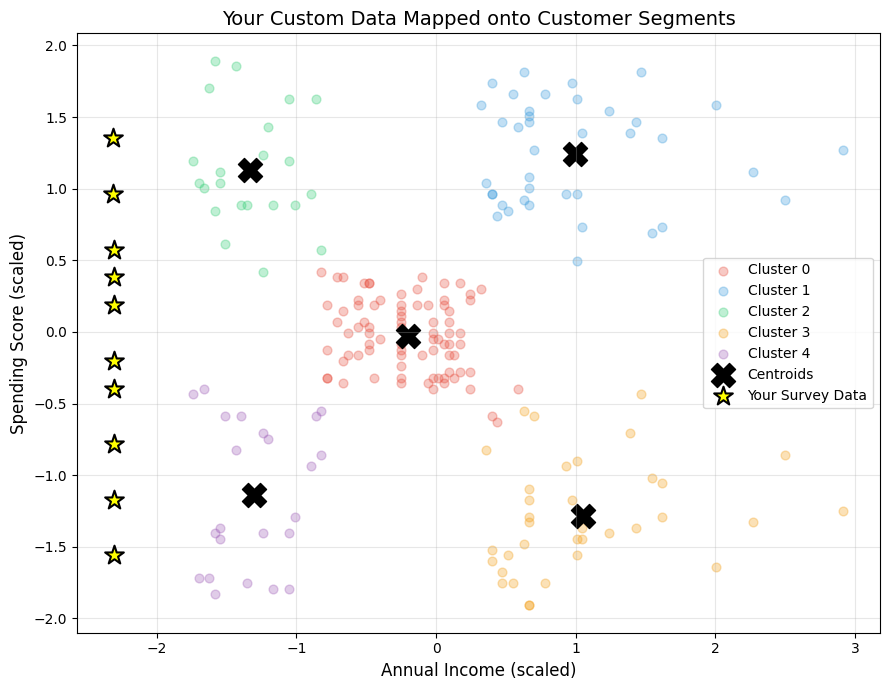

In [14]:
plt.figure(figsize=(9, 7))

# Plot original clusters (faded)
for cluster_id in range(optimal_k):
    cluster_points = X_scaled[kmeans.labels_ == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                s=40, c=colors[cluster_id % len(colors)],
                label=f"Cluster {cluster_id}", alpha=0.3)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='black', marker='X', label='Centroids')

# Plot YOUR custom data points (bright, on top)
plt.scatter(custom_X_scaled[:, 0], custom_X_scaled[:, 1],
            s=200, c='yellow', marker='*', edgecolors='black',
            linewidths=1.5, label='Your Survey Data', zorder=5)

plt.title("Your Custom Data Mapped onto Customer Segments", fontsize=14)
plt.xlabel("Annual Income (scaled)", fontsize=12)
plt.ylabel("Spending Score (scaled)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("custom_data_clusters.png", dpi=150)
plt.show()


In [15]:
from google.colab import files

files.download("220124.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>